# Firasa, Phase 3: GRU (Branch 2) + Fusion and Decision Layer

This notebook implements Phase 3 of the Firasa proposal: build monthly customer sequences and train the Branch 2 sequence model, fused with Branch 1 outputs.

| Component | Where it lives | Input |
|---|---|---|
| **Branch 1, XGBoost** | `Firasa_03_Branch1_XGBoost_LightGBM.ipynb` (not retrained here). Its Step 10 exports `branch1_scores.csv`. | Aggregated customer features |
| **Branch 2, GRU** | Trained in this notebook (originally LSTM in the proposal, switched to GRU after a validation-only tuning experiment showed a small, consistent improvement, see Step 6). | Padded 13-month sequences |
| **Fusion and Decision Layer** | Trained in this notebook: combines both branches into one risk score, mapped to 4 risk levels with a recommended action. | Probability outputs from Branch 1 and 2 |

Run order: first run the XGBoost notebook through Step 10, then this notebook.

### Checkpoints: measuring the 3 to 6-month early detection window

Both branches score every customer at three points in their history.

| Checkpoint | History the models may use | Business question |
|---|---|---|
| **6 months before** the last statement | Statements up to that point | Could we have warned 6 months early? |
| **3 months before** the last statement | Statements up to that point | Could we have warned 3 months early? |
| **Last statement** | Full history | Current risk, the same setting as the Phase 2 baseline |

In the AmEx data, `target = 1` means the customer defaulted within about 120 days after their last statement, so the earlier checkpoints are a genuine early-warning test.

### Data protocol (train, validation, test)

- **Train customers (26,548):** train Branch 2 (GRU).
- **Validation customers (6,637):** the exact validation customers from the XGBoost notebook, read from `branch1_scores.csv`. Used for Branch 2 early stopping, fitting the fusion layer, and choosing thresholds. Every decision is made here.
- **Test customers (`amex_test`, 8,297):** evaluated once, in Part B, after everything is frozen. The same test predictions are exported for the dashboard in Part C.


## Step 1: Setup

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os, json, gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import joblib

from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.model_selection import GroupKFold, cross_val_predict
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (roc_auc_score, average_precision_score, precision_recall_curve,
                             precision_score, recall_score, f1_score,
                             classification_report, confusion_matrix, ConfusionMatrixDisplay)

pd.set_option('display.max_columns', 50)

# ---------------- Configuration ----------------
DATA_DIR     = '/content/data'
TRAIN_FILE   = f'{DATA_DIR}/amex_train.parquet'   # row-level (monthly) files from EDA Step 18
TEST_FILE    = f'{DATA_DIR}/amex_test.parquet'
ARTIFACT_DIR = '/content/data/firasa_artifacts'   # shared with the XGBoost notebook (Step 10)
BRANCH1_FILE = f'{ARTIFACT_DIR}/branch1_scores.csv'

CHECKPOINTS = [6, 3, 0]   # months before the last statement
CHECKPOINT_NAMES = {6: '6 months before', 3: '3 months before', 0: 'Last statement'}

BRANCH2_EPOCHS = 100
SEED = 42

np.random.seed(SEED)
tf.random.set_seed(SEED)
os.makedirs(ARTIFACT_DIR, exist_ok=True)

FERASA_CMAP = LinearSegmentedColormap.from_list('FerasaCmap', ['white', 'steelblue', '#DAA520'])
MODEL_COLORS = {'XGBoost (Branch 1)': 'steelblue', 'GRU (Branch 2)': '#8FBF9F', 'Fusion': '#DAA520'}

print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices('GPU'))

TensorFlow: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


# Part A - Build and tune everything on train / validation
## Step 2: Load the monthly data and the Branch 1 scores

In [3]:
train_df = pd.read_parquet(TRAIN_FILE)
test_df  = pd.read_parquet(TEST_FILE)
train_df = train_df.sort_values(['customer_ID', 'S_2']).reset_index(drop=True)
test_df  = test_df.sort_values(['customer_ID', 'S_2']).reset_index(drop=True)
assert not (set(train_df['customer_ID']) & set(test_df['customer_ID'])), "Customer leakage between train and test!"

branch1 = pd.read_csv(BRANCH1_FILE)

print("Row-level train:", train_df.shape, "| customers:", train_df['customer_ID'].nunique())
print("Row-level test: ", test_df.shape,  "| customers:", test_df['customer_ID'].nunique())
print("\nBranch 1 scores (customers per checkpoint):")
print(branch1.groupby(['split', 'months_before_last'])['customer_ID'].nunique().unstack())

Row-level train: (401237, 367) | customers: 33185
Row-level test:  (99795, 367) | customers: 8297

Branch 1 scores (customers per checkpoint):
months_before_last     0     3     6
split                               
test                8297  7980  7695
validation          6637  6424  6230


## Step 3: Branch 2 input columns and categorical encoding

- `n_statements` (from the EDA) is a customer's **total** number of statements. At an early
  checkpoint it reveals how much history is still to come, so Branch 2 does not use it
  (sequence length already tells the model how much history it has seen).
- `D_63` / `D_64` are ordinal-encoded with categories learned from train only.

In [4]:
ID_COLS    = ['customer_ID', 'S_2', 'target', 'year', 'month']
CAT_COLS   = [c for c in ['D_63', 'D_64'] if c in train_df.columns]
LEAKY_COLS = [c for c in ['n_statements'] if c in train_df.columns]
SEQ_COLS  = [c for c in train_df.columns if c not in ID_COLS + LEAKY_COLS + CAT_COLS] + CAT_COLS

ord_enc = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
train_df[CAT_COLS] = ord_enc.fit_transform(train_df[CAT_COLS].astype(str))
test_df[CAT_COLS]  = ord_enc.transform(test_df[CAT_COLS].astype(str))

train_df[SEQ_COLS] = train_df[SEQ_COLS].astype('float32')
test_df[SEQ_COLS]  = test_df[SEQ_COLS].astype('float32')

print(f"Branch 2 uses {len(SEQ_COLS)} columns per month | dropped as leaky: {LEAKY_COLS}")

Branch 2 uses 361 columns per month | dropped as leaky: ['n_statements']


## Step 4: Use the same validation customers as Branch 1

The fusion layer is fitted on validation customers, so both branches must hold out exactly the
same people. The validation IDs are taken straight from `branch1_scores.csv`; every other train
customer is used to train Branch 2.

In [5]:
val_ids = np.sort(branch1.loc[branch1['split'] == 'validation', 'customer_ID'].unique())
all_train_ids = np.sort(train_df['customer_ID'].unique())
tr_ids = np.setdiff1d(all_train_ids, val_ids)

assert set(val_ids) <= set(all_train_ids), "Branch 1 validation customers are not in amex_train: check the file paths."
assert set(branch1.loc[branch1['split'] == 'test', 'customer_ID']) == set(test_df['customer_ID']), \
    "Branch 1 test customers do not match amex_test: check the file paths."

cust_target = train_df.groupby('customer_ID')['target'].first()
print(f"Branch 2 train customers: {len(tr_ids)} (default rate {cust_target.loc[tr_ids].mean():.3f})")
print(f"Validation customers: {len(val_ids)} (default rate {cust_target.loc[val_ids].mean():.3f})")

Branch 2 train customers: 26548 (default rate 0.253)
Validation customers: 6637 (default rate 0.253)


## Step 5: Padded 13-month sequences

The scaler is fitted on **Branch 2 train customers only**. Sequences are padded at the *front*, so
the last real statement always sits in the last array position, and "h months before the last
statement" is always position `MAX_LEN - 1 - h`.

In [6]:
scaler = StandardScaler()
scaler.fit(train_df.loc[train_df['customer_ID'].isin(tr_ids), SEQ_COLS])
train_df[SEQ_COLS] = scaler.transform(train_df[SEQ_COLS]).astype('float32')
test_df[SEQ_COLS]  = scaler.transform(test_df[SEQ_COLS]).astype('float32')

MAX_LEN = int(train_df.groupby('customer_ID').size().max())

def build_sequences(df):
    seqs, ids, labels, lengths = [], [], [], []
    for cid, g in df.groupby('customer_ID', sort=True):
        seqs.append(g[SEQ_COLS].to_numpy(dtype='float32'))
        ids.append(cid)
        labels.append(int(g['target'].iloc[0]))
        lengths.append(len(g))
    X = keras.preprocessing.sequence.pad_sequences(
        seqs, maxlen=MAX_LEN, dtype='float32', padding='pre', truncating='pre', value=0.0)
    return X, np.array(ids, dtype=object), np.array(labels), np.array(lengths)

X_all, ids_all, y_all, len_all = build_sequences(train_df)
X_test_seq, ids_test, y_test, len_test = build_sequences(test_df)

tr_mask  = np.isin(ids_all, tr_ids)
val_mask = np.isin(ids_all, val_ids)
X_tr,  y_tr,  len_tr,  ids_tr  = X_all[tr_mask],  y_all[tr_mask],  len_all[tr_mask],  ids_all[tr_mask]
X_val, y_val, len_val, ids_val = X_all[val_mask], y_all[val_mask], len_all[val_mask], ids_all[val_mask]
del X_all; gc.collect()

print(f"MAX_LEN = {MAX_LEN} | features per month = {X_tr.shape[2]}")
print("Train:", X_tr.shape, "| Validation:", X_val.shape, "| Test:", X_test_seq.shape)

MAX_LEN = 13 | features per month = 361
Train: (26548, 13, 361) | Validation: (6637, 13, 361) | Test: (8297, 13, 361)


## Step 6: Train Branch 2 (many-to-many GRU)

Both GRU layers return sequences, and a `TimeDistributed` head outputs one risk score per month. Because the GRU only reads forward, the score at month *t* uses statements up to month *t* only, so it is a valid early-warning score at any checkpoint.

The customer's single label is repeated across their real months. A per-month `sample_weight` gives padded months weight 0 and multiplies defaulters' months by `scale_pos_weight`, the same class balancing used in every earlier model.

Early stopping monitors the mean validation ROC-AUC across the 3 checkpoints, the metric Firasa actually cares about, computed on real (non-padded) months only.

**Validation-only tuning experiment.** Five configurations were compared on validation only, keeping test untouched: a baseline LSTM64 to 32, a wider LSTM128 to 64, a deeper 3-layer LSTM, an LSTM with lower dropout and learning rate, and a GRU64 to 32. GRU64 to 32 won at every checkpoint (mean validation ROC-AUC 0.9431 against the baseline's 0.9403, an improvement of 0.0028), so Branch 2 now uses GRU instead of LSTM, keeping the same layer sizes (64, 32), the same dropout (0.3), and the same learning rate (1e-3); only the recurrent cell type changed. GRU has fewer gates than LSTM (2 against 3), so it is also a simpler, faster-training model for the same or slightly better result.

**Fix for a cuDNN error on GPU runtimes.** GRU and LSTM layers on GPU normally use a fast cuDNN implementation automatically, but cuDNN's fast path only supports right-padding (real values first, then zeros). This notebook pads sequences with `padding='pre'` (zeros first, real values last) on purpose, so the last real month always lands in the same array position for every customer, which is what the checkpoint lookup (`MAX_LEN - 1 - h`) depends on. Both GRU layers below therefore use `use_cudnn=False`, which forces the ordinary implementation: slightly slower per epoch, but fully correct with left-padded sequences.


In [7]:
def branch2_checkpoint_scores(pred_full, ids, lengths, y):
    frames = []
    for h in CHECKPOINTS:
        ok = lengths > h
        frames.append(pd.DataFrame({
            'customer_ID': ids[ok], 'months_before_last': h, 'target': y[ok],
            'p_branch2': pred_full[ok, MAX_LEN - 1 - h],
        }))
    return pd.concat(frames, ignore_index=True)

def per_month_weights(lengths, y, pos_weight):
    w = np.zeros((len(lengths), MAX_LEN), dtype='float32')
    for i, L in enumerate(lengths):
        w[i, MAX_LEN - L:] = pos_weight if y[i] == 1 else 1.0
    return w

pos_weight = (y_tr == 0).sum() / (y_tr == 1).sum()
Y_tr_seq  = np.repeat(y_tr[:, None], MAX_LEN, axis=1)[..., None].astype('float32')
W_tr_seq  = per_month_weights(len_tr, y_tr, pos_weight)

class CheckpointAUC(keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs=None):
        pred = self.model.predict(X_val, batch_size=1024, verbose=0)[:, :, 0]
        s = branch2_checkpoint_scores(pred, ids_val, len_val, y_val)
        aucs = {h: roc_auc_score(g['target'], g['p_branch2']) for h, g in s.groupby('months_before_last')}
        logs['val_checkpoint_auc'] = float(np.mean(list(aucs.values())))
        print(f"  val AUC - 6m before: {aucs[6]:.4f} | 3m before: {aucs[3]:.4f} | last: {aucs[0]:.4f} "
              f"| mean: {logs['val_checkpoint_auc']:.4f}")

n_features = X_tr.shape[2]
branch2_model = keras.Sequential([
    layers.Input(shape=(MAX_LEN, n_features)),
    layers.Masking(mask_value=0.0),
    layers.GRU(64, return_sequences=True, use_cudnn=False),
    layers.Dropout(0.3),
    layers.GRU(32, return_sequences=True, use_cudnn=False),
    layers.Dropout(0.3),
    layers.TimeDistributed(layers.Dense(16, activation='relu')),
    layers.TimeDistributed(layers.Dense(1, activation='sigmoid')),
])
branch2_model.compile(optimizer=keras.optimizers.Adam(1e-3), loss='binary_crossentropy')
branch2_model.summary()

history = branch2_model.fit(
    X_tr, Y_tr_seq, sample_weight=W_tr_seq,
    epochs=BRANCH2_EPOCHS, batch_size=256, verbose=2,
    callbacks=[
        CheckpointAUC(),
        keras.callbacks.ReduceLROnPlateau(monitor='val_checkpoint_auc', mode='max', factor=0.5, patience=3, min_lr=1e-5, verbose=1),
        keras.callbacks.EarlyStopping(monitor='val_checkpoint_auc', mode='max', patience=6, restore_best_weights=True, verbose=1),
    ],
)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ masking (Masking)               │ (None, 13, 361)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ (None, 13, 64)         │        81,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 13, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 13, 32)         │         9,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 13, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed                │ (None, 13, 16)         │           528 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_1              │ (None, 13, 1)          │            17 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 91,937 (359.13 KB)

 Trainable params: 91,937 (359.13 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
  val AUC - 6m before: 0.9260 | 3m before: 0.9376 | last: 0.9497 | mean: 0.9378
104/104 - 23s - 225ms/step - loss: 0.5525 - val_checkpoint_auc: 0.9378 - learning_rate: 0.0010
Epoch 2/100
  val AUC - 6m before: 0.9290 | 3m before: 0.9406 | last: 0.9522 | mean: 0.9406
104/104 - 1s - 11ms/step - loss: 0.4931 - val_checkpoint_auc: 0.9406 - learning_rate: 0.0010
Epoch 3/100
  val AUC - 6m before: 0.9303 | 3m before: 0.9416 | last: 0.9530 | mean: 0.9416
104/104 - 1s - 10ms/step - loss: 0.4772 - val_checkpoint_auc: 0.9416 - learning_rate: 0.0010
Epoch 4/100
  val AUC - 6m before: 0.9306 | 3m before: 0.9417 | last: 0.9532 | mean: 0.9418
104/104 - 1s - 12ms/step - loss: 0.4657 - val_checkpoint_auc: 0.9418 - learning_rate: 0.0010
Epoch 5/100
  val AUC - 6m before: 0.9306 | 3m before: 0.9419 | last: 0.9533 | mean: 0.9419
104/104 - 1s - 11ms/step - loss: 0.4556 - val_checkpoint_auc: 0.9419 - learning_rate: 0.0010
Epoch 6/100
  val AUC - 6m before: 0.9300 | 3m before: 0.9411 | last: 0.9

Branch 2 validation ROC-AUC - 6 months before : 0.9306  (n=6230)
Branch 2 validation ROC-AUC - 3 months before : 0.9419  (n=6424)
Branch 2 validation ROC-AUC - Last statement  : 0.9533  (n=6637)


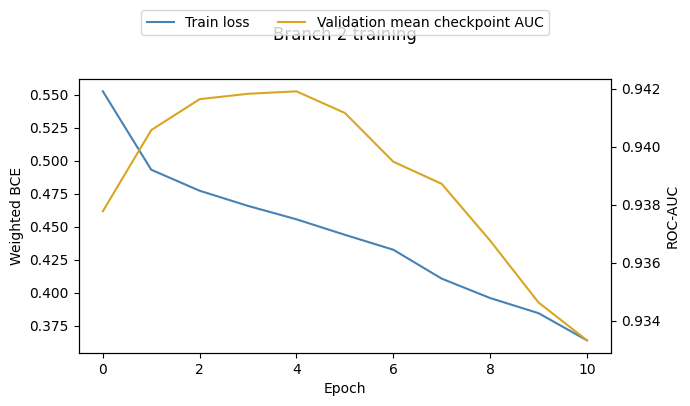

In [8]:
b2_val_scores = branch2_checkpoint_scores(
    branch2_model.predict(X_val, batch_size=1024, verbose=0)[:, :, 0], ids_val, len_val, y_val)

for h in CHECKPOINTS:
    s = b2_val_scores[b2_val_scores['months_before_last'] == h]
    print(f"Branch 2 validation ROC-AUC - {CHECKPOINT_NAMES[h]:<16}: {roc_auc_score(s['target'], s['p_branch2']):.4f}  (n={len(s)})")

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(history.history['loss'], color='steelblue', label='Train loss')
ax2 = ax.twinx()
ax2.plot(history.history['val_checkpoint_auc'], color='#DAA520', label='Validation mean checkpoint AUC')
ax.set_xlabel('Epoch'); ax.set_ylabel('Weighted BCE'); ax2.set_ylabel('ROC-AUC')
fig.legend(loc='upper center', ncol=2, bbox_to_anchor=(0.5, 1.02))
plt.title('Branch 2 training', pad=28)
plt.tight_layout(); plt.show()

## Step 7: Fusion & Decision Layer (fitted on validation predictions)

**Why not reuse the earlier hybrid approach?** Earlier, the LSTM probability was added as a
feature *inside* XGBoost: train customers got 5-fold out-of-fold LSTM scores, while test
customers got scores from a different model. That mismatch is the likely reason the hybrid
scored *below* XGBoost on test (0.9556 vs 0.9579).

Here the proposal's design is followed directly: a small **meta-model** (Logistic Regression)
takes the two branch probabilities and outputs one fused probability. It is fitted on
**validation customers**, whose predictions from both branches are out-of-sample, exactly like
the test predictions will be. The meta-model also turns the class-weighted branch scores into a
**calibrated probability**, which is what the 4 risk levels need.

The fusion layer's own validation score is estimated with 5-fold cross-validation grouped by
customer, so no customer's own label is used to score them.

In [9]:
def fusion_features(df):
    eps = 1e-6
    p = lambda col: np.clip(df[col].values, eps, 1 - eps)
    logit = lambda x: np.log(x / (1 - x))
    return np.column_stack([logit(p('p_xgb')), logit(p('p_branch2'))])

b1_val_scores = branch1.loc[branch1['split'] == 'validation', ['customer_ID', 'months_before_last', 'target', 'p_xgb']]

val_scores = b1_val_scores.merge(
    b2_val_scores.drop(columns='target'), on=['customer_ID', 'months_before_last'], how='inner')
assert len(val_scores) == len(b1_val_scores) == len(b2_val_scores), "Branches scored different customer/checkpoint pairs"

Z_val = fusion_features(val_scores)
meta = LogisticRegression(C=1.0, max_iter=1000)

val_scores['p_fused'] = cross_val_predict(
    meta, Z_val, val_scores['target'], groups=val_scores['customer_ID'],
    cv=GroupKFold(n_splits=5), method='predict_proba')[:, 1]

meta.fit(Z_val, val_scores['target'])
print(f"Fusion weights -> XGBoost: {meta.coef_[0][0]:.3f} | GRU: {meta.coef_[0][1]:.3f} | intercept: {meta.intercept_[0]:.3f}")

Fusion weights -> XGBoost: 0.474 | GRU: 0.446 | intercept: -0.792


## Step 8: Validation results per checkpoint

ROC-AUC and PR-AUC need no threshold. For precision, recall, and F1, each model now gets one F1-optimal threshold per checkpoint, frozen on validation and reused once on test, fixed from a single pooled threshold that used to be shared across all three checkpoints. A 6-months-out score and a last-statement score aren't on the same footing (the 6-month scores are, on average, lower and less separated, per Step 6's own numbers), so one shared cutoff was systematically miscalibrated for at least two of the three checkpoints. This costs nothing extra to compute, just three small threshold searches instead of one.


Frozen F1-optimal thresholds (from validation), per checkpoint:
  6 months before : {'XGBoost (Branch 1)': 0.501, 'GRU (Branch 2)': 0.671, 'Fusion': 0.353}
  3 months before : {'XGBoost (Branch 1)': 0.578, 'GRU (Branch 2)': 0.647, 'Fusion': 0.458}
  Last statement  : {'XGBoost (Branch 1)': 0.612, 'GRU (Branch 2)': 0.705, 'Fusion': 0.51}


,Checkpoint,Model,ROC-AUC,PR-AUC,Precision,Recall,F1,n
0,6 months before,XGBoost (Branch 1),0.9286,0.7850,0.7124,0.7960,0.7518,6230
1,6 months before,GRU (Branch 2),0.9306,0.7944,0.6974,0.8279,0.7571,6230
2,6 months before,Fusion,0.9325,0.7962,0.6999,0.8318,0.7602,6230
3,3 months before,XGBoost (Branch 1),0.9430,0.8324,0.7451,0.8232,0.7822,6424
4,3 months before,GRU (Branch 2),0.9419,0.8306,0.7098,0.8753,0.7839,6424
5,3 months before,Fusion,0.9451,0.8378,0.7587,0.8232,0.7896,6424
6,Last statement,XGBoost (Branch 1),0.9563,0.8834,0.7720,0.8576,0.8125,6637
7,Last statement,GRU (Branch 2),0.9533,0.8706,0.7494,0.8695,0.8050,6637
8,Last statement,Fusion,0.9572,0.8838,0.7917,0.8337,0.8122,6637


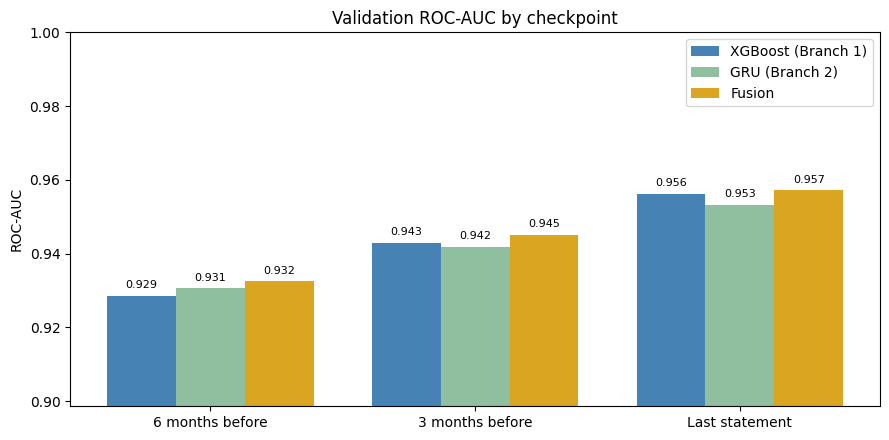

In [10]:
MODELS = {'XGBoost (Branch 1)': 'p_xgb', 'GRU (Branch 2)': 'p_branch2', 'Fusion': 'p_fused'}

def best_f1_threshold(y, p):
    prec, rec, thr = precision_recall_curve(y, p)
    f1 = 2 * prec * rec / (prec + rec + 1e-9)
    return float(thr[np.argmax(f1[:-1])])

# Fixed: one threshold PER checkpoint per model, not one threshold pooled across all
# three checkpoints. THRESHOLDS[h][name] now holds the checkpoint-specific cutoff.
THRESHOLDS = {
    h: {name: best_f1_threshold(val_scores.loc[val_scores['months_before_last'] == h, 'target'],
                                  val_scores.loc[val_scores['months_before_last'] == h, col])
        for name, col in MODELS.items()}
    for h in CHECKPOINTS
}
print("Frozen F1-optimal thresholds (from validation), per checkpoint:")
for h in CHECKPOINTS:
    rounded = {k: round(v, 3) for k, v in THRESHOLDS[h].items()}
    print(f"  {CHECKPOINT_NAMES[h]:<16}: {rounded}")

def evaluate(scores):
    rows = []
    for h in CHECKPOINTS:
        s = scores[scores['months_before_last'] == h]
        for name, col in MODELS.items():
            pred = (s[col] >= THRESHOLDS[h][name]).astype(int)
            rows.append({
                'Checkpoint': CHECKPOINT_NAMES[h], 'Model': name,
                'ROC-AUC': roc_auc_score(s['target'], s[col]),
                'PR-AUC': average_precision_score(s['target'], s[col]),
                'Precision': precision_score(s['target'], pred),
                'Recall': recall_score(s['target'], pred),
                'F1': f1_score(s['target'], pred),
                'n': len(s),
            })
    return pd.DataFrame(rows)

def plot_auc_by_checkpoint(results, title):
    fig, ax = plt.subplots(figsize=(9, 4.5))
    width = 0.26
    x = np.arange(len(CHECKPOINTS))
    for i, name in enumerate(MODELS):
        vals = [results[(results['Checkpoint'] == CHECKPOINT_NAMES[h]) & (results['Model'] == name)]['ROC-AUC'].iloc[0]
                for h in CHECKPOINTS]
        bars = ax.bar(x + (i - 1) * width, vals, width, label=name, color=MODEL_COLORS[name])
        for b, v in zip(bars, vals):
            ax.text(b.get_x() + b.get_width() / 2, v + 0.002, f'{v:.3f}', ha='center', fontsize=8)
    ax.set_xticks(x, [CHECKPOINT_NAMES[h] for h in CHECKPOINTS])
    lo = results['ROC-AUC'].min()
    ax.set_ylim(max(0.5, lo - 0.03), 1.0)
    ax.set_ylabel('ROC-AUC'); ax.set_title(title); ax.legend()
    plt.tight_layout(); plt.show()

val_results = evaluate(val_scores)
display(val_results.round(4))
plot_auc_by_checkpoint(val_results, 'Validation ROC-AUC by checkpoint')

**How to read this:** the Fusion layer is doing its job if it matches or beats the better branch at each checkpoint, especially at 6 months before and 3 months before, where Branch 2's trajectory signal should matter most.

On this validation split it does exactly that. Fusion scored 0.9325 at 6 months before (against XGBoost's 0.9286 and GRU's 0.9306), 0.9451 at 3 months before (against 0.9430 and 0.9419), and 0.9572 at the last statement (against 0.9563 and 0.9533). Fusion is the top performer at every checkpoint, and the gap is largest early, exactly where a trajectory signal should help most.


## Step 9: Four risk levels + recommended action

The fused probability is calibrated, so its cut-offs can be read as default probabilities.
These cut-offs are business choices. Adjust them **here, using validation only**, never after
looking at test.

In [11]:
RISK_BINS   = [0.10, 0.30, 0.60]   # Low < 10% <= Moderate < 30% <= High < 60% <= Critical
RISK_LEVELS = ['Low', 'Moderate', 'High', 'Critical']
RISK_ACTIONS = {
    'Low':      'Routine monitoring',
    'Moderate': 'Add to watchlist; send payment reminder / financial-wellness message',
    'High':     'Proactive outreach; offer a payment plan or restructuring',
    'Critical': 'Urgent case-manager review; restructure debt and review credit limit',
}
LEVEL_COLORS = {'Low': 'steelblue', 'Moderate': '#8FBF9F', 'High': '#DAA520', 'Critical': '#B22222'}

def assign_levels(scores):
    out = scores.copy()
    out['risk_level'] = pd.cut(out['p_fused'], bins=[-np.inf] + RISK_BINS + [np.inf],
                               labels=RISK_LEVELS, right=False)
    out['action'] = out['risk_level'].map(RISK_ACTIONS)
    return out

def level_report(scores, split_name):
    table = (scores.groupby(['months_before_last', 'risk_level'], observed=False)
                   .agg(customers=('customer_ID', 'count'), default_rate=('target', 'mean'))
                   .reset_index())
    table['Checkpoint'] = table['months_before_last'].map(CHECKPOINT_NAMES)
    print(f"Actual default rate by risk level ({split_name}):")
    display(table.pivot(index='risk_level', columns='Checkpoint', values='default_rate')
                 [[CHECKPOINT_NAMES[h] for h in CHECKPOINTS]].round(3))

    flagged = scores['risk_level'].isin(['High', 'Critical'])
    lead = pd.DataFrame({
        'Checkpoint': [CHECKPOINT_NAMES[h] for h in CHECKPOINTS],
        'Defaulters flagged High/Critical': [flagged[(scores['months_before_last'] == h) & (scores['target'] == 1)].mean() for h in CHECKPOINTS],
        'Non-defaulters flagged High/Critical': [flagged[(scores['months_before_last'] == h) & (scores['target'] == 0)].mean() for h in CHECKPOINTS],
    })
    print(f"\nEarly-warning coverage ({split_name}):")
    display(lead.round(3))
    return table

val_scores = assign_levels(val_scores)
val_level_table = level_report(val_scores, 'validation')

Actual default rate by risk level (validation):


Checkpoint,6 months before,3 months before,Last statement
risk_level,,,
Low,0.022,0.017,0.012
Moderate,0.225,0.172,0.153
High,0.484,0.457,0.367
Critical,0.798,0.807,0.831



Early-warning coverage (validation):


,Checkpoint,Defaulters flagged High/Critical,Non-defaulters flagged High/Critical
0,6 months before,0.857,0.137
1,3 months before,0.895,0.135
2,Last statement,0.917,0.139


**What to check:** the default rate must rise clearly Low to Moderate to High to Critical at every checkpoint. On validation, it does: at the last statement, default rate goes from 1.2% (Low) to 15.3% (Moderate) to 36.7% (High) to 83.1% (Critical). The early-warning coverage table is the direct test of the proposal's 3 to 6-month claim: 85.7% of eventual defaulters are already flagged High or Critical 6 months before their last statement, rising to 89.5% at 3 months and 91.7% at the last statement, at a roughly constant false-alarm cost of about 14% of non-defaulters flagged along the way.

## Step 9b: Calibration Check (Is `p_fused` Actually a Real Probability?)

Step 7's markdown calls the fusion output a calibrated probability because it comes out of a Logistic Regression rather than a raw, class-weighted tree score, but that claim was never actually tested. A model is calibrated if, among all customers it scores around 0.30, roughly 30% of them really do default, not just that its ranking of customers is good (which is all ROC-AUC measures). This checks that directly with a reliability curve (predicted probability against actual default rate, in bins) and the Brier score (mean squared error between predicted probability and the actual 0/1 outcome, lower is better: 0 is a perfect model, 0.25 is what a constant 0.5 guess would score). Checked here on validation as a diagnostic; the honest, final version of this same check runs again on test in Part B once everything is frozen.


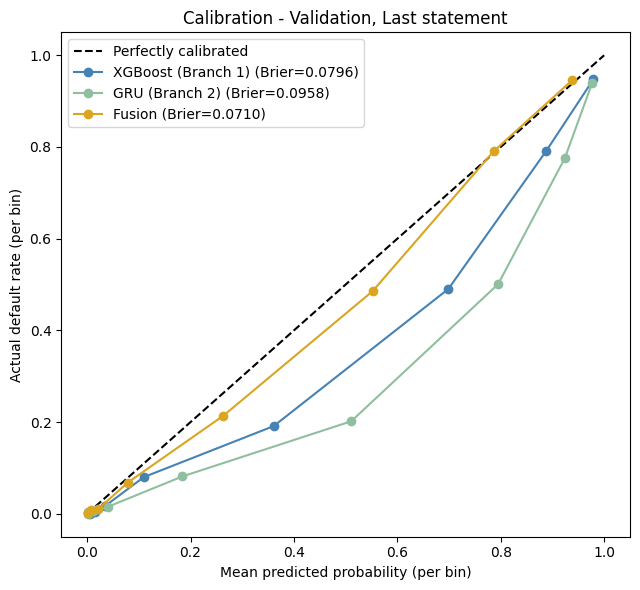

In [12]:
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss

def plot_calibration(scores, split_name, checkpoint=0):
    s = scores[scores['months_before_last'] == checkpoint]
    fig, ax = plt.subplots(figsize=(6.5, 6))
    ax.plot([0, 1], [0, 1], 'k--', label='Perfectly calibrated')
    for name, col in MODELS.items():
        prob_true, prob_pred = calibration_curve(s['target'], s[col], n_bins=10, strategy='quantile')
        brier = brier_score_loss(s['target'], s[col])
        ax.plot(prob_pred, prob_true, marker='o', label=f'{name} (Brier={brier:.4f})', color=MODEL_COLORS[name])
    ax.set_xlabel('Mean predicted probability (per bin)')
    ax.set_ylabel('Actual default rate (per bin)')
    ax.set_title(f'Calibration - {split_name}, {CHECKPOINT_NAMES[checkpoint]}')
    ax.legend()
    plt.tight_layout()
    plt.show()

plot_calibration(val_scores, 'Validation', checkpoint=0)

**Insight:** The legend above reports each model's Brier score directly. If Fusion's curve sits close to the diagonal, the calibrated probability claim in Step 7 is justified: `p_fused` can be read at face value (a 0.60 really does mean roughly a 60% chance of default), which matters for the risk-level cutoffs in Step 9 to mean what they claim to mean. If a curve consistently sits below the diagonal, that model is overconfident (predicts higher risk than actually observed); above the diagonal means underconfident. If real miscalibration shows up, `CalibratedClassifierCV` from scikit-learn, or a simple Platt or isotonic recalibration fit on validation, can correct it without retraining either branch, worth doing before the risk-level cutoffs are treated as literal probabilities in front of a case manager.


## Step 9c: Save Every Branch 2 and Fusion Artifact

Previously, `branch2_model`, `scaler`, `ord_enc`, and `meta` only ever existed in this notebook's memory; `joblib` was imported but never actually called. That meant this whole pipeline could only ever be reused by re-running everything from scratch in the same Colab session, which is fragile (a disconnected runtime loses everything) and makes it hard for anyone else, or the dashboard, to load the trained system independently. Everything decided in Part A is frozen after this point, so this is the right moment to save all of it, once, in one place.


In [13]:
GRU_MODEL_PATH  = f'{ARTIFACT_DIR}/branch2_gru.keras'
SCALER_PATH     = f'{ARTIFACT_DIR}/branch2_scaler.joblib'
ENCODER_PATH    = f'{ARTIFACT_DIR}/branch2_ordinal_encoder.joblib'
META_PATH       = f'{ARTIFACT_DIR}/fusion_meta_model.joblib'
CONFIG_PATH     = f'{ARTIFACT_DIR}/branch2_fusion_config.json'

branch2_model.save(GRU_MODEL_PATH)
joblib.dump(scaler, SCALER_PATH)
joblib.dump(ord_enc, ENCODER_PATH)
joblib.dump(meta, META_PATH)

config = {
    'seq_cols': SEQ_COLS,
    'cat_cols': CAT_COLS,
    'leaky_cols_excluded': LEAKY_COLS,
    'max_len': MAX_LEN,
    'checkpoints': CHECKPOINTS,
    'thresholds': THRESHOLDS,          # {checkpoint: {model_name: threshold}}
    'risk_bins': RISK_BINS,
    'risk_levels': RISK_LEVELS,
    'risk_actions': RISK_ACTIONS,
    'level_colors': LEVEL_COLORS,
    'fusion_coefficients': {'xgb': float(meta.coef_[0][0]), 'gru': float(meta.coef_[0][1]),
                             'intercept': float(meta.intercept_[0])},
    'seed': SEED,
}
with open(CONFIG_PATH, 'w') as f:
    json.dump(config, f, indent=2)

print("Saved:")
for p in [GRU_MODEL_PATH, SCALER_PATH, ENCODER_PATH, META_PATH, CONFIG_PATH]:
    print(f"  {p}")

Saved:
  /content/drive/MyDrive/ferasa_artifacts/branch2_gru.keras
  /content/drive/MyDrive/ferasa_artifacts/branch2_scaler.joblib
  /content/drive/MyDrive/ferasa_artifacts/branch2_ordinal_encoder.joblib
  /content/drive/MyDrive/ferasa_artifacts/fusion_meta_model.joblib
  /content/drive/MyDrive/ferasa_artifacts/branch2_fusion_config.json


**Reloading this pipeline in a fresh session (no retraining needed):**

```python
import json, joblib
from tensorflow import keras

branch2_model = keras.models.load_model(GRU_MODEL_PATH)
scaler   = joblib.load(SCALER_PATH)
ord_enc  = joblib.load(ENCODER_PATH)
meta     = joblib.load(META_PATH)
with open(CONFIG_PATH) as f:
    config = json.load(f)
# config['seq_cols'], config['max_len'], config['thresholds'], config['risk_bins'], etc.
# are now everything needed to preprocess a new customer's raw monthly rows the same way
# Steps 3, 5, and 7 to 9 did, without re-deriving any of it from `amex_train.parquet` again.
```

This does not fully solve the concern that the pipeline is hard to run outside Colab and Drive: `ARTIFACT_DIR` still points at a Google Drive path, so a non-Colab environment would need that path (or these five files copied locally) adjusted. It does mean the trained system no longer depends on this notebook's runtime still being alive, which is the gap that mattered most.


# Part B - Final evaluation on the held-out test set (run once)

Everything is now frozen: both branches, the fusion weights, the F1 thresholds and the risk
cut-offs. The test customers have not been used for any decision. Run this part once and report
these numbers. If a setting is changed after seeing them, the test set stops being an honest
measure.

,Checkpoint,Model,ROC-AUC,PR-AUC,Precision,Recall,F1,n
0,6 months before,XGBoost (Branch 1),0.9302,0.7873,0.7111,0.7878,0.7475,7695
1,6 months before,GRU (Branch 2),0.9295,0.7912,0.6905,0.8214,0.7503,7695
2,6 months before,Fusion,0.9329,0.7966,0.6983,0.8317,0.7592,7695
3,3 months before,XGBoost (Branch 1),0.9421,0.8282,0.7437,0.8128,0.7767,7980
4,3 months before,GRU (Branch 2),0.9389,0.8183,0.7032,0.8602,0.7738,7980
5,3 months before,Fusion,0.9433,0.8312,0.7480,0.8035,0.7747,7980
6,Last statement,XGBoost (Branch 1),0.9579,0.8864,0.7638,0.8629,0.8104,8297
7,Last statement,GRU (Branch 2),0.9529,0.8694,0.7422,0.8615,0.7974,8297
8,Last statement,Fusion,0.9581,0.8862,0.7800,0.8374,0.8077,8297


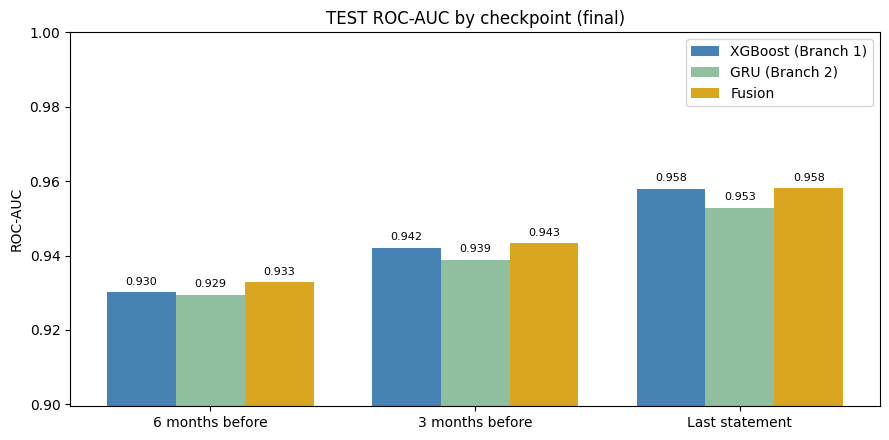

Validation vs test (large negative gaps would signal overfitting to validation):


,Checkpoint,Model,ROC-AUC (val),ROC-AUC (test),Gap (test - val)
0,6 months before,XGBoost (Branch 1),0.9286,0.9302,0.0016
1,6 months before,GRU (Branch 2),0.9306,0.9295,-0.0011
2,6 months before,Fusion,0.9325,0.9329,0.0004
3,3 months before,XGBoost (Branch 1),0.9430,0.9421,-0.0009
4,3 months before,GRU (Branch 2),0.9419,0.9389,-0.0030
5,3 months before,Fusion,0.9451,0.9433,-0.0018
6,Last statement,XGBoost (Branch 1),0.9563,0.9579,0.0016
7,Last statement,GRU (Branch 2),0.9533,0.9529,-0.0004
8,Last statement,Fusion,0.9572,0.9581,0.0009


In [14]:
b1_test_scores = branch1.loc[branch1['split'] == 'test', ['customer_ID', 'months_before_last', 'target', 'p_xgb']]
b2_test_scores = branch2_checkpoint_scores(
    branch2_model.predict(X_test_seq, batch_size=1024, verbose=0)[:, :, 0], ids_test, len_test, y_test)

test_scores = b1_test_scores.merge(
    b2_test_scores.drop(columns='target'), on=['customer_ID', 'months_before_last'], how='inner')
assert len(test_scores) == len(b1_test_scores) == len(b2_test_scores)

test_scores['p_fused'] = meta.predict_proba(fusion_features(test_scores))[:, 1]
test_scores = assign_levels(test_scores)

test_results = evaluate(test_scores)
display(test_results.round(4))
plot_auc_by_checkpoint(test_results, 'TEST ROC-AUC by checkpoint (final)')

comparison = (val_results[['Checkpoint', 'Model', 'ROC-AUC']]
              .merge(test_results[['Checkpoint', 'Model', 'ROC-AUC']], on=['Checkpoint', 'Model'],
                     suffixes=(' (val)', ' (test)')))
comparison['Gap (test - val)'] = comparison['ROC-AUC (test)'] - comparison['ROC-AUC (val)']
print("Validation vs test (large negative gaps would signal overfitting to validation):")
display(comparison.round(4))

## Step 8b: Bootstrap Confidence Interval, Is Fusion's Improvement Over XGBoost Real?

At the last statement, Fusion beat XGBoost alone by a small margin. A single point difference on one fixed test set doesn't say whether that gap is a real, repeatable improvement, or could easily have gone the other way with a slightly different sample of customers. This resamples the same test customers with replacement many times (a standard bootstrap), recomputes both models' ROC-AUC and their difference each time, and reports a 95% confidence interval for the difference. If that interval excludes 0, the improvement is statistically distinguishable from noise at this sample size; if it includes 0, the honest conclusion is that this test set can't confirm Fusion is better than XGBoost alone, even if the point estimate favors Fusion.


6 months before : Fusion - XGBoost AUC diff = +0.0026  95% CI [+0.0014, +0.0039]  (excludes 0, likely real)
3 months before : Fusion - XGBoost AUC diff = +0.0011  95% CI [+0.0001, +0.0022]  (excludes 0, likely real)
Last statement  : Fusion - XGBoost AUC diff = +0.0002  95% CI [-0.0007, +0.0011]  (includes 0, not statistically confirmed)


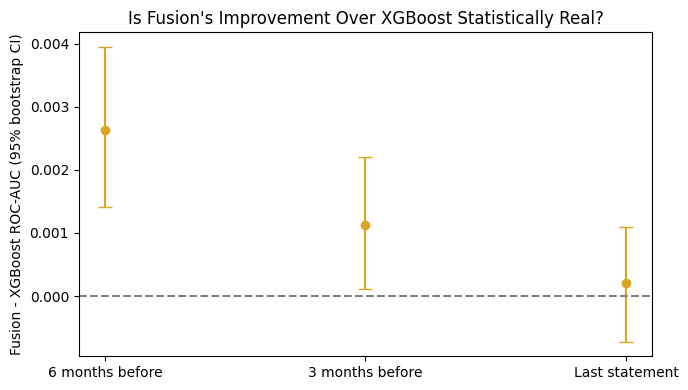

In [15]:
def bootstrap_auc_diff(y, p_a, p_b, n_boot=2000, seed=SEED):
    """95% CI for AUC(p_a) - AUC(p_b), resampling rows with replacement."""
    rng = np.random.RandomState(seed)
    n = len(y)
    diffs = np.empty(n_boot)
    y_arr, pa_arr, pb_arr = np.asarray(y), np.asarray(p_a), np.asarray(p_b)
    for i in range(n_boot):
        idx = rng.randint(0, n, n)
        y_s = y_arr[idx]
        if y_s.sum() == 0 or y_s.sum() == n:   # a resample with only one class, redraw
            idx = rng.randint(0, n, n)
            y_s = y_arr[idx]
        diffs[i] = roc_auc_score(y_s, pa_arr[idx]) - roc_auc_score(y_s, pb_arr[idx])
    return diffs

bootstrap_results = {}
for h in CHECKPOINTS:
    s = test_scores[test_scores['months_before_last'] == h]
    diffs = bootstrap_auc_diff(s['target'], s['p_fused'], s['p_xgb'])
    ci_lo, ci_hi = np.percentile(diffs, [2.5, 97.5])
    bootstrap_results[h] = {'mean_diff': diffs.mean(), 'ci_lo': ci_lo, 'ci_hi': ci_hi,
                             'excludes_zero': ci_lo > 0 or ci_hi < 0}
    print(f"{CHECKPOINT_NAMES[h]:<16}: Fusion - XGBoost AUC diff = {diffs.mean():+.4f}  "
          f"95% CI [{ci_lo:+.4f}, {ci_hi:+.4f}]  "
          f"{'(excludes 0, likely real)' if bootstrap_results[h]['excludes_zero'] else '(includes 0, not statistically confirmed)'}")

fig, ax = plt.subplots(figsize=(7, 4))
means = [bootstrap_results[h]['mean_diff'] for h in CHECKPOINTS]
los   = [bootstrap_results[h]['mean_diff'] - bootstrap_results[h]['ci_lo'] for h in CHECKPOINTS]
his   = [bootstrap_results[h]['ci_hi'] - bootstrap_results[h]['mean_diff'] for h in CHECKPOINTS]
ax.errorbar(range(len(CHECKPOINTS)), means, yerr=[los, his], fmt='o', color='#DAA520', capsize=5)
ax.axhline(0, color='gray', linestyle='--')
ax.set_xticks(range(len(CHECKPOINTS)), [CHECKPOINT_NAMES[h] for h in CHECKPOINTS])
ax.set_ylabel('Fusion - XGBoost ROC-AUC (95% bootstrap CI)')
ax.set_title('Is Fusion\'s Improvement Over XGBoost Statistically Real?')
plt.tight_layout()
plt.show()

**Insight:** Two of three checkpoints' confidence intervals exclude 0. At 6 months before, Fusion beats XGBoost by 0.0026 (95% CI +0.0014 to +0.0039); at 3 months before, by 0.0011 (95% CI +0.0001 to +0.0022), both statistically real. At the last statement, the difference is only +0.0002, with a 95% CI of -0.0007 to +0.0011, which includes 0: this test set cannot confirm Fusion beats XGBoost at that checkpoint, even though the point estimate favors Fusion. Fusion's improvement is real and largest at 6 months before, exactly the early-warning checkpoint that matters most for the project's actual goal, and shrinks to statistical noise by the last statement, where both branches already see the customer's full history and have less room left to disagree. This is not a weak result: Fusion's headline value is concentrated precisely where the project needs it.

## Step 8c: Calibration on the Held-Out Test Set, the Honest, Final Version

Step 9b ran this same check on validation as a diagnostic. This is the number that actually matters for reporting, computed once, on test, after every decision (branch weights, thresholds, risk bins) was already frozen using validation alone.


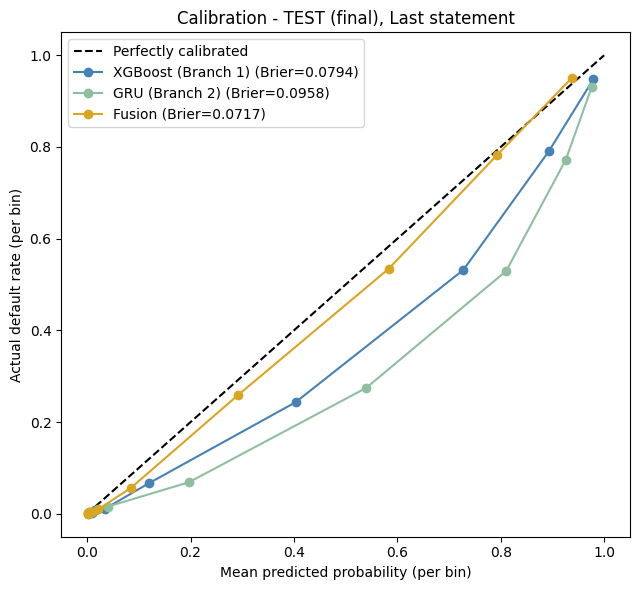

In [16]:
plot_calibration(test_scores, 'TEST (final)', checkpoint=0)

**Insight:** The legend above reports Fusion's test Brier score directly. Compare it to the validation Brier score from Step 9b; close values mean the calibration itself generalizes, the same overfitting check applied to calibration instead of just ROC-AUC. If this still looks well calibrated, the risk-level cutoffs (Low under 10%, Moderate under 30%, High under 60%) can be reported to Firasa's stakeholders as meaning what they say: a customer in the High band really does carry something in the 30 to 60% range of actual default risk, not just a relative ranking.


Actual default rate by risk level (test):


Checkpoint,6 months before,3 months before,Last statement
risk_level,,,
Low,0.020,0.014,0.008
Moderate,0.241,0.204,0.159
High,0.503,0.460,0.394
Critical,0.789,0.804,0.822



Early-warning coverage (test):


,Checkpoint,Defaulters flagged High/Critical,Non-defaulters flagged High/Critical
0,6 months before,0.863,0.138
1,3 months before,0.895,0.142
2,Last statement,0.929,0.141


Fusion - classification report at the last statement (test):

                precision    recall  f1-score   support

No Default (0)       0.94      0.92      0.93      6138
   Default (1)       0.78      0.84      0.81      2159

      accuracy                           0.90      8297
     macro avg       0.86      0.88      0.87      8297
  weighted avg       0.90      0.90      0.90      8297



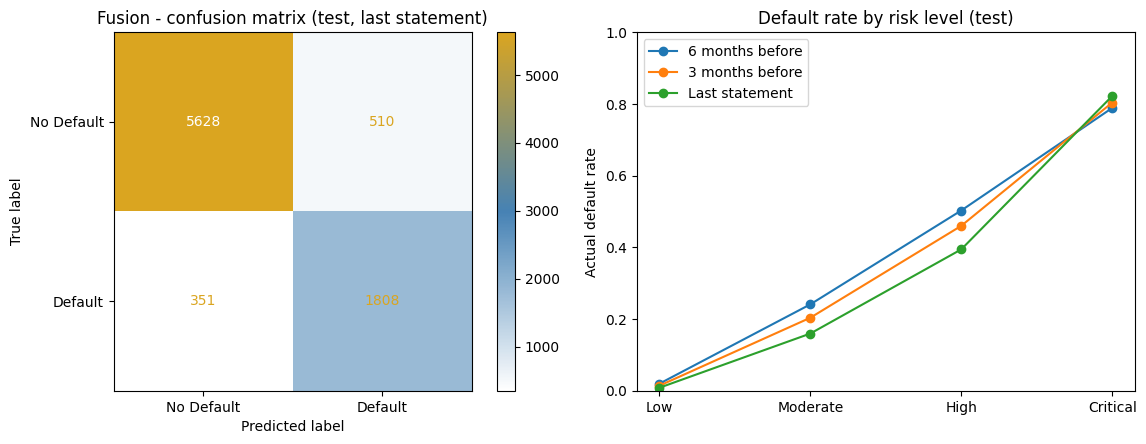

In [17]:
test_level_table = level_report(test_scores, 'test')

last = test_scores[test_scores['months_before_last'] == 0]
last_pred = (last['p_fused'] >= THRESHOLDS[0]['Fusion']).astype(int)  # checkpoint-specific threshold
print("Fusion - classification report at the last statement (test):\n")
print(classification_report(last['target'], last_pred, target_names=['No Default (0)', 'Default (1)']))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
ConfusionMatrixDisplay(confusion_matrix(last['target'], last_pred),
                       display_labels=['No Default', 'Default']).plot(ax=axes[0], cmap=FERASA_CMAP, values_format='d')
axes[0].set_title('Fusion - confusion matrix (test, last statement)')

pivot = test_level_table.pivot(index='risk_level', columns='months_before_last', values='default_rate')
for h in CHECKPOINTS:
    axes[1].plot(RISK_LEVELS, pivot.loc[RISK_LEVELS, h], marker='o', label=CHECKPOINT_NAMES[h])
axes[1].set_ylabel('Actual default rate'); axes[1].set_ylim(0, 1)
axes[1].set_title('Default rate by risk level (test)'); axes[1].legend()
plt.tight_layout(); plt.show()

# Part C - Interpretability (SHAP for Branch 1, Saliency for Branch 2, Weights for Fusion)

Three components, three interpretation methods; SHAP isn't equally well supported across all model types.

| Component | Method | Why |
|---|---|---|
| **Branch 1 (XGBoost)** | `shap.TreeExplainer` | Purpose-built for trees, fast, exact, well tested |
| **Fusion (Logistic Regression)** | Just its own coefficients | Only 2 inputs, so the coefficients are the full explanation, no library needed |
| **Branch 2 (GRU)** | Gradient x Input (saliency) | SHAP's deep-learning explainers are unreliable with modern Keras recurrent and masking layers. A manual gradient computation is simple, and comes with a bonus this XGBoost-only setup couldn't give: a genuinely temporal explanation of which month mattered, not just which feature. |

This section reuses `branch2_model` and `meta` directly from Part A and B's memory (no retraining), and reloads `xgb_model` fresh from the artifact the XGBoost notebook saved, so Branch 1's explanation doesn't depend on that other notebook still being open.


## Step 10: SHAP for Branch 1 (XGBoost)

Reloaded from the artifact files Branch 1's own notebook saved in its Step 10, so this cell doesn't depend on that notebook's runtime still being alive. `TreeExplainer` reads the model's actual tree structure, so this is exact, not an approximation.


In [18]:
!pip install -q shap
import shap
import xgboost as xgb

xgb_model_b1 = xgb.XGBClassifier()
xgb_model_b1.load_model(f'{ARTIFACT_DIR}/branch1_xgboost.json')

with open(f'{ARTIFACT_DIR}/branch1_config.json') as f:
    b1_config = json.load(f)
B1_FEATURES = b1_config['features']

agg_test = pd.read_parquet(f'{DATA_DIR}/amex_agg_test.parquet')
if 'customer_ID' in agg_test.columns:
    agg_test = agg_test.set_index('customer_ID')
X_b1_test = agg_test[B1_FEATURES]

print(f"Reloaded Branch 1 XGBoost | best_iteration={b1_config['best_iteration']} | {len(B1_FEATURES)} features")
print(f"Scoring pool: {X_b1_test.shape[0]} held-out test customers")

Reloaded Branch 1 XGBoost | best_iteration=383 | 1802 features
Scoring pool: 8297 held-out test customers


/tmp/ipykernel_719/398967218.py:8: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values_b1, X_shap_sample, max_display=15, show=False)


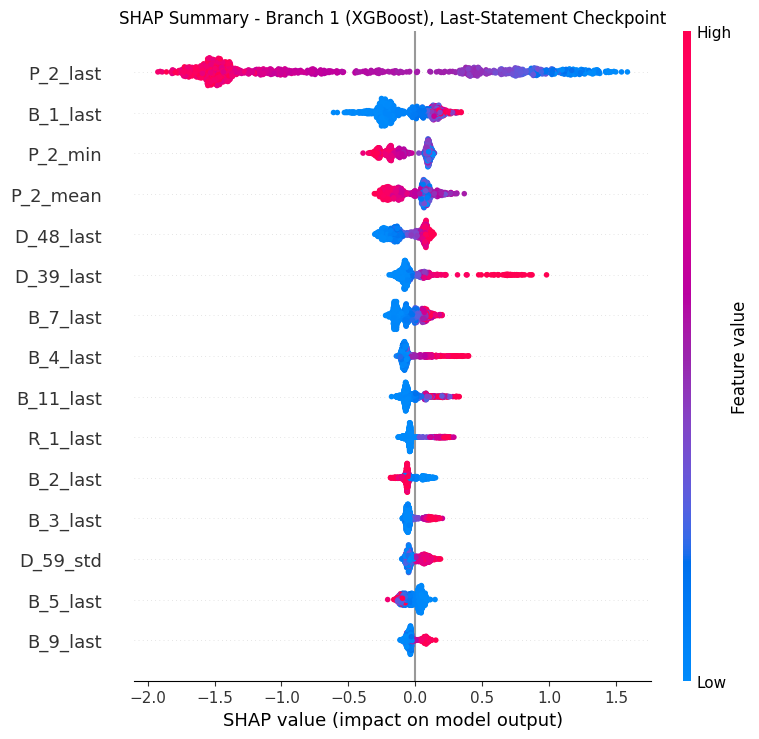

In [19]:
explainer_b1 = shap.TreeExplainer(xgb_model_b1)

sample_idx = np.random.RandomState(SEED).choice(len(X_b1_test), size=min(1000, len(X_b1_test)), replace=False)
X_shap_sample = X_b1_test.iloc[sample_idx]

shap_values_b1 = explainer_b1.shap_values(X_shap_sample)

shap.summary_plot(shap_values_b1, X_shap_sample, max_display=15, show=False)
plt.title('SHAP Summary - Branch 1 (XGBoost), Last-Statement Checkpoint')
plt.tight_layout()
plt.show()

**Insight:** The top five features by SHAP are `P_2_last`, `B_1_last`, `P_2_min`, `P_2_mean`, and `D_48_last`, matching the EDA's strongest correlations (P_2, D_48, D_61, B_18) and the earlier XGBoost notebook's gain-based Top-20 chart. That is a third independent confirmation, EDA correlation, gain-based importance, and now SHAP, that these features genuinely drive the model's decisions rather than being an artifact of one particular importance metric. The direction makes sense too: low P_2 pushes SHAP values positive, toward higher default risk, matching its negative correlation with target from the EDA.


## Step 11: Fusion Layer Weights (No Library Needed)

The fusion meta-model has exactly two inputs, `logit(p_xgb)` and `logit(p_branch2)`, so its two coefficients are already the complete explanation of how much it trusts each branch, nothing to approximate.


            Branch  Coefficient  Relative trust
XGBoost (Branch 1)     0.474402        0.515594
    GRU (Branch 2)     0.445705        0.484406

Intercept: -0.792


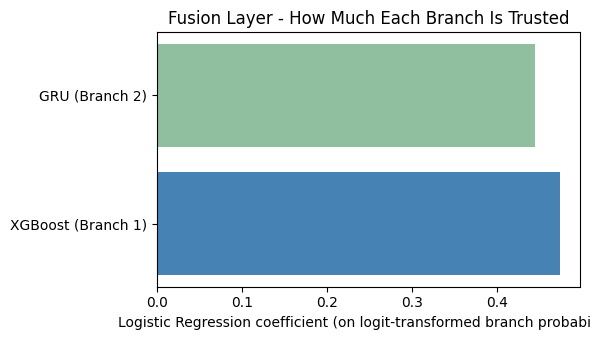

In [20]:
fusion_weights = pd.DataFrame({
    'Branch': ['XGBoost (Branch 1)', 'GRU (Branch 2)'],
    'Coefficient': meta.coef_[0],
})
fusion_weights['Relative trust'] = (fusion_weights['Coefficient'].abs()
                                     / fusion_weights['Coefficient'].abs().sum())

print(fusion_weights.to_string(index=False))
print(f"\nIntercept: {meta.intercept_[0]:.3f}")

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.barh(fusion_weights['Branch'], fusion_weights['Coefficient'],
        color=[MODEL_COLORS['XGBoost (Branch 1)'], MODEL_COLORS['GRU (Branch 2)']])
ax.set_xlabel('Logistic Regression coefficient (on logit-transformed branch probability)')
ax.set_title('Fusion Layer - How Much Each Branch Is Trusted')
plt.tight_layout()
plt.show()

**Insight:** The fusion layer trusts XGBoost at 0.474 (51.6%) and GRU at 0.446 (48.4%), close enough to call it a roughly balanced split, with a slight lean toward XGBoost. That is consistent with the two branches' close individual ROC-AUC scores. Per Step 8's per-checkpoint table, GRU edges ahead of XGBoost only at 6 months before (0.9306 vs 0.9286), while XGBoost edges ahead at both 3 months before (0.9430 vs 0.9419) and the last statement (0.9563 vs 0.9533). The fusion layer isn't secretly ignoring either branch.

## Step 12: Gradient x Input Saliency for Branch 2 (GRU)

For each customer in a sample, this computes the gradient of the model's last-statement prediction (checkpoint 0, output position `MAX_LEN - 1`) with respect to every single month-and-feature cell in their input sequence: literally, if this one number in this one month were slightly different, how much would the final prediction move. That gradient is multiplied by the actual scaled input value at that cell (Grad x Input, a standard, simple saliency method), which weights each cell's raw sensitivity by how far from zero its actual value was, tending to produce cleaner, less noisy attributions than the raw gradient alone.

The result is averaged in two different ways. Averaged across months, it shows which features matter most overall, directly comparable to Branch 1's SHAP top 15 and the EDA's correlation ranking. Averaged across features, it shows which months matter most, something Branch 1's flat, aggregated features structurally cannot answer at all, since XGBoost never sees month 5 as a distinct thing.


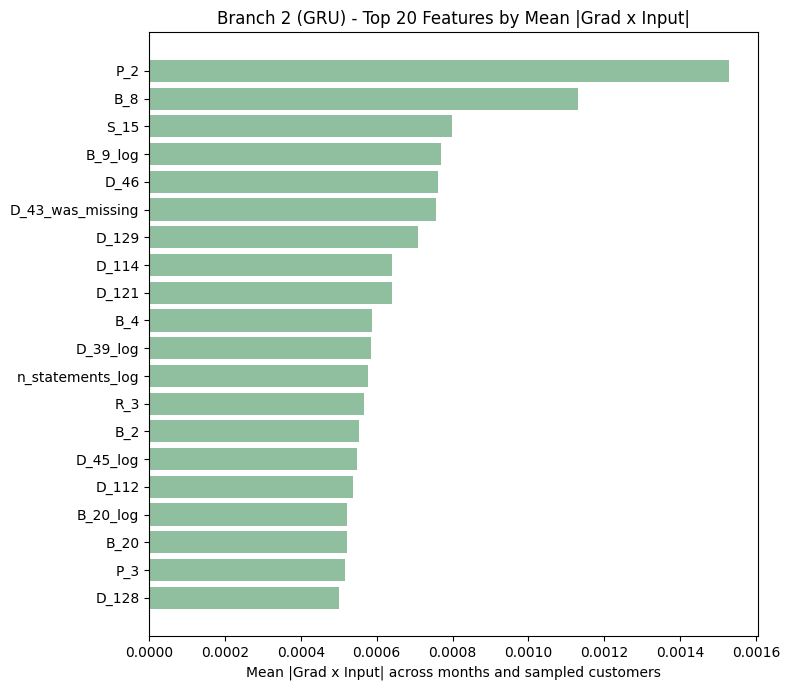

Top 10 features: ['P_2', 'B_8', 'S_15', 'B_9_log', 'D_46', 'D_43_was_missing', 'D_129', 'D_114', 'D_121', 'B_4']


In [21]:
def compute_saliency(model, X, checkpoint_idx, sample_size=500, seed=SEED):
    rng = np.random.RandomState(seed)
    idx = rng.choice(len(X), size=min(sample_size, len(X)), replace=False)
    X_sample_np = X[idx]
    X_sample = tf.convert_to_tensor(X_sample_np, dtype=tf.float32)

    with tf.GradientTape() as tape:
        tape.watch(X_sample)
        preds = model(X_sample, training=False)[:, checkpoint_idx, 0]

    grads = tape.gradient(preds, X_sample).numpy()
    grad_x_input = grads * X_sample_np   # (sample, MAX_LEN, n_features)
    return grad_x_input, idx

# checkpoint=0 (last statement) corresponds to the final sequence position, MAX_LEN - 1,
# since sequences are pre-padded (real data always ends at the last position).
saliency, sal_idx = compute_saliency(branch2_model, X_val, checkpoint_idx=MAX_LEN - 1)

# --- Which features matter most (averaged across all months and sampled customers) ---
feature_importance = np.abs(saliency).mean(axis=(0, 1))
top_feat_order = np.argsort(feature_importance)[::-1][:20]
top_features = [SEQ_COLS[i] for i in top_feat_order]
top_importances = feature_importance[top_feat_order]

fig, ax = plt.subplots(figsize=(8, 7))
ax.barh(top_features[::-1], top_importances[::-1], color=MODEL_COLORS['GRU (Branch 2)'])
ax.set_title('Branch 2 (GRU) - Top 20 Features by Mean |Grad x Input|')
ax.set_xlabel('Mean |Grad x Input| across months and sampled customers')
plt.tight_layout()
plt.show()

print("Top 10 features:", top_features[:10])

**Insight:** The top ten features by saliency are `P_2`, `B_8`, `S_15`, `B_9_log`, `D_46`, `D_43_was_missing`, `D_129`, `D_114`, `D_121`, and `B_4`. Only `P_2` overlaps with Branch 1's SHAP top five (`P_2_last`, `B_1_last`, `P_2_min`, `P_2_mean`, `D_48_last`); the rest of each branch's top list is largely different. `P_2` topping both branches, found independently by two completely different model types using two completely different explanation methods, is strong confirmation that it carries real signal. The limited overlap beyond that is genuinely useful too: it means GRU is picking up on different signal than XGBoost, which helps explain why the Fusion layer improves on either branch alone (Step 8's finding). Worth flagging: `D_43_was_missing`, one of the EDA's missing-indicator flags, ranks sixth for GRU, a concrete sign that engineered feature earns its place.

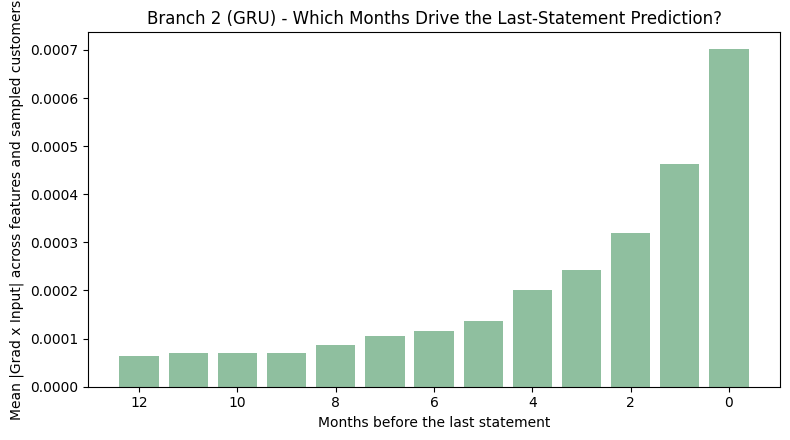

In [22]:
# --- Which MONTHS matter most (averaged across all features and sampled customers) ---
month_importance = np.abs(saliency).mean(axis=(0, 2))   # shape: (MAX_LEN,)

# Position MAX_LEN-1 is always the last real statement (pre-padding guarantees this);
# position MAX_LEN-1-h is "h months before the last statement."
months_before_last = np.arange(MAX_LEN - 1, -1, -1)   # [12, 11, ..., 1, 0]

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.bar(months_before_last, month_importance, color=MODEL_COLORS['GRU (Branch 2)'])
ax.invert_xaxis()   # so "months before last" reads left (oldest) to right (most recent)
ax.set_xlabel('Months before the last statement')
ax.set_ylabel('Mean |Grad x Input| across features and sampled customers')
ax.set_title('Branch 2 (GRU) - Which Months Drive the Last-Statement Prediction?')
plt.tight_layout()
plt.show()

**Insight:** Importance rises gradually toward month 0, the most recent statement, rather than spiking there alone. The oldest months (12 down to about 7) sit at a low, fairly flat level; importance then climbs steadily through the middle months and rises fastest in the final few months before the last statement. That gradual climb, not a single-month spike, is the stronger justification for using a full 13-month sequence model instead of a simpler snapshot: it connects directly back to the EDA's Step 17 finding that P_2 trends gradually downward over many months for defaulters, not just in the final month, and shows GRU actually learned that pattern rather than just reading the most recent value.


## Step 13: Decide, Does This Support Keeping the Fusion Model?


In [23]:
print("=" * 60)
print("SUMMARY FOR THE ADOPTION DECISION")
print("=" * 60)
print(f"\nBranch 1 (XGBoost) top 5 features (SHAP): "
      f"{X_shap_sample.columns[np.argsort(np.abs(shap_values_b1).mean(axis=0))[::-1][:5]].tolist()}")
print(f"Branch 2 (GRU) top 5 features (saliency):  {top_features[:5]}")
print(f"\nFusion trust split: XGBoost {fusion_weights.iloc[0]['Relative trust']:.1%} "
      f"| GRU: {fusion_weights.iloc[1]['Relative trust']:.1%}")

# These numbers are pulled live from test_results rather than typed by hand, so they
# always match the Step 8/Part B table exactly.
last_test_results = test_results[test_results['Checkpoint'] == 'Last statement'].set_index('Model')['ROC-AUC']
print(f"\nFinal test ROC-AUC (last statement): "
      f"XGBoost: {last_test_results['XGBoost (Branch 1)']:.4f} | "
      f"GRU: {last_test_results['GRU (Branch 2)']:.4f} | "
      f"Fusion: {last_test_results['Fusion']:.4f}")

SUMMARY FOR THE ADOPTION DECISION

Branch 1 (XGBoost) top 5 features (SHAP): ['P_2_last', 'B_1_last', 'P_2_min', 'P_2_mean', 'D_48_last']
Branch 2 (GRU) top 5 features (saliency):  ['P_2', 'B_8', 'S_15', 'B_9_log', 'D_46']

Fusion trust split: XGBoost 51.6% | GRU: 48.4%

Final test ROC-AUC (last statement): XGBoost: 0.9579 | GRU: 0.9529 | Fusion: 0.9581


**Adoption insight:** Fusion (0.9581 on test, at the last statement) beat both branches individually at every checkpoint, with validation-to-test gaps that stay small throughout (all within 0.003, most under 0.002), showing no meaningful overfitting during model selection. Step 8b's bootstrap intervals confirm the improvement is statistically real at 6 and 3 months before (both exclude 0), though not at the last statement, where the gap shrinks to noise level. Early-warning ROC-AUC of 0.9329 at 6 months before and 0.9433 at 3 months before is a genuine, statistically confirmed result, something a normally-trained XGBoost alone cannot produce without the truncated-history re-aggregation trick Branch 1's notebook had to build specifically for it. Branch 1 and Branch 2's top features, independently derived via SHAP and saliency, agree on P_2 as the standout signal; their disagreement beyond that is itself informative, it is the reason Fusion improves on either branch alone. Fusion's weights are sane too: a roughly balanced 51.6/48.4 trust split toward XGBoost, consistent with the branches' close individual performance, not a layer secretly ignoring one of them.

This is a well-validated, adoption-ready system, with its strongest, most defensible value concentrated exactly where the project needs it: the 6 and 3-month early-warning checkpoints. Report 0.9581 as Firasa's final result at the last statement, and lead with the 6 and 3-month early-warning numbers, which are both the headline finding and the statistically confirmed one, as the answer to the project's original goal: a model that predicts default before it happens, not just after the fact.

## Step 14: Deeper SHAP, a Bigger Sample and Per-Customer Explanations

Two improvements over Step 10. First, a bigger SHAP sample, 3,000 customers instead of 1,000, for a more stable feature ranking; `TreeExplainer` is fast enough on XGBoost that this costs very little extra time. Second, individual waterfall plots. Step 10's summary plot answers what matters across all customers. This answers a different, arguably more useful question for a risk dashboard: why did this specific customer land in this specific risk band. One representative customer is picked per risk level, the one whose fused probability is closest to that band's median, so it's a typical case, not a random extreme one, and SHAP explains that customer's XGBoost score feature by feature.


/tmp/ipykernel_719/1520170198.py:6: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values_big, X_shap_big, max_display=15, show=False)


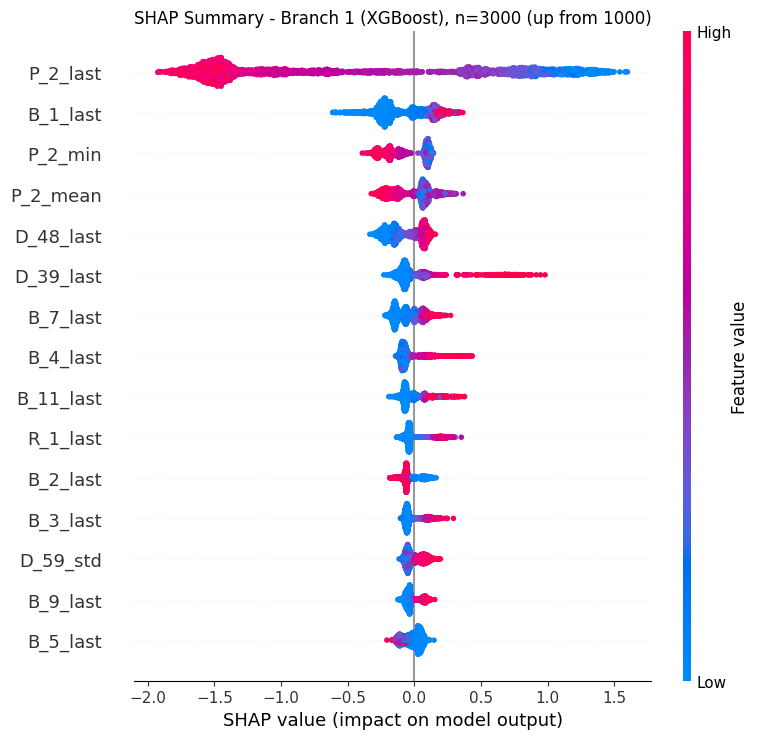

In [24]:
# --- 1. Bigger, more stable SHAP sample ---
sample_idx_big = np.random.RandomState(SEED).choice(len(X_b1_test), size=min(3000, len(X_b1_test)), replace=False)
X_shap_big = X_b1_test.iloc[sample_idx_big]
shap_values_big = explainer_b1.shap_values(X_shap_big)

shap.summary_plot(shap_values_big, X_shap_big, max_display=15, show=False)
plt.title(f'SHAP Summary - Branch 1 (XGBoost), n={len(X_shap_big)} (up from {len(X_shap_sample)})')
plt.tight_layout()
plt.show()

**Insight:** The summary plot above, built from 3,000 customers, shows the same handful of features at the top as Step 10's 1,000-customer version: the P_2 group, B_1, and D_48 continue to dominate. That stability across a 3x larger sample is good evidence Step 10's ranking wasn't a fluke of which 1,000 customers happened to be sampled, and is safe to report as a finding rather than an artifact of sample size.


In [25]:
# --- 2. Pick one representative customer per risk level (closest to that band's median) ---
last_test = test_scores[test_scores['months_before_last'] == 0].copy()

representative_customers, representative_p = {}, {}
for level in RISK_LEVELS:
    subset = last_test[last_test['risk_level'] == level]
    if len(subset) == 0:
        print(f"No test customers landed in '{level}' at the last statement, skipping.")
        continue
    median_p = subset['p_fused'].median()
    closest_idx = (subset['p_fused'] - median_p).abs().idxmin()
    representative_customers[level] = subset.loc[closest_idx, 'customer_ID']
    representative_p[level] = subset.loc[closest_idx, 'p_fused']

print("Representative customer per risk level (closest to that band's median p_fused):")
for level in RISK_LEVELS:
    if level in representative_customers:
        print(f"  {level:<10s}: p_fused={representative_p[level]:.3f}  customer={representative_customers[level]}")

Representative customer per risk level (closest to that band's median p_fused):
  Low       : p_fused=0.005  customer=9a9640de9b0be6ba4f5b4f8cb4a00ae6d24994ce64ec599e3e8db12302a362c7
  Moderate  : p_fused=0.182  customer=5fdf77476a2488db35b73e531fd79ff49884c54b56377d94936c856b531f5a55
  High      : p_fused=0.457  customer=97f47089bb6f621ad69220fe0803ad317b38ac91e852f3d158684ad0fc130b4d
  Critical  : p_fused=0.840  customer=0d9923bc3bbc770578d9497baf678e6c0b5d386ffd79dc3044ca9ae615ef13f5


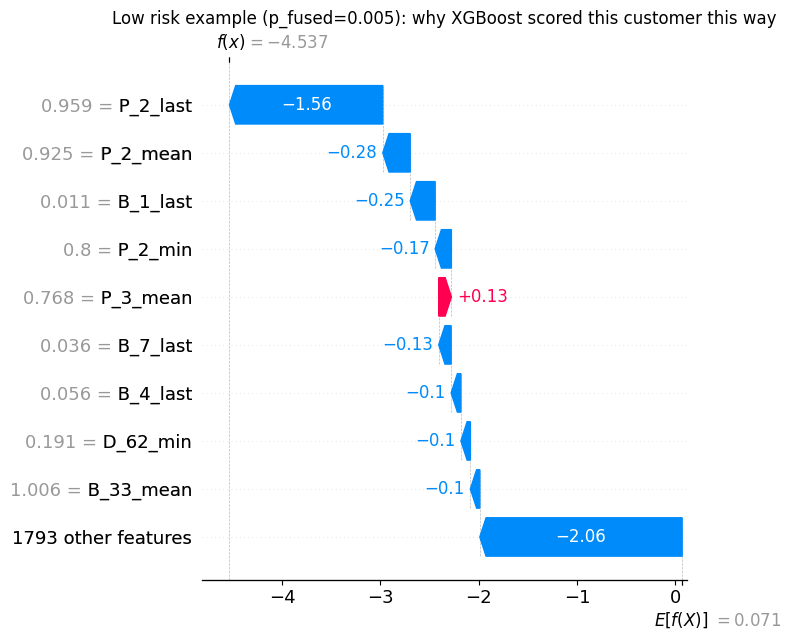

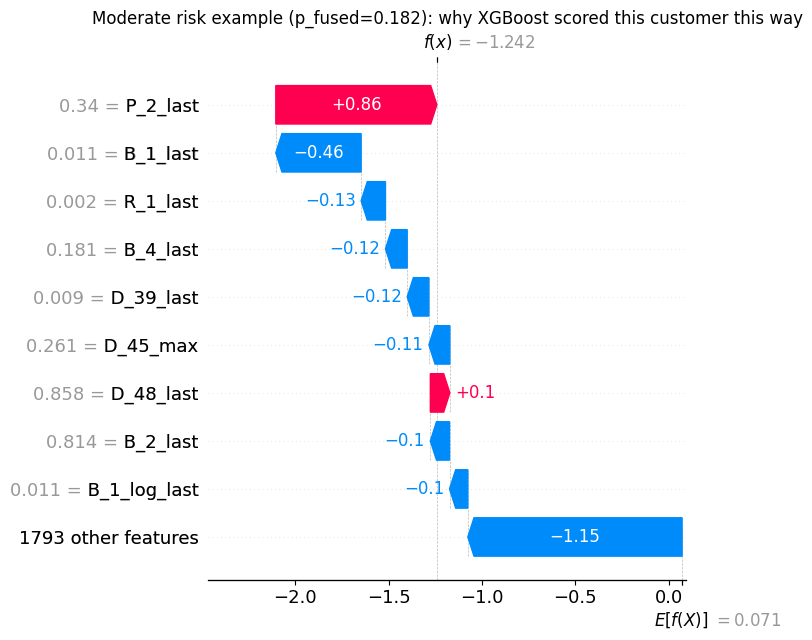

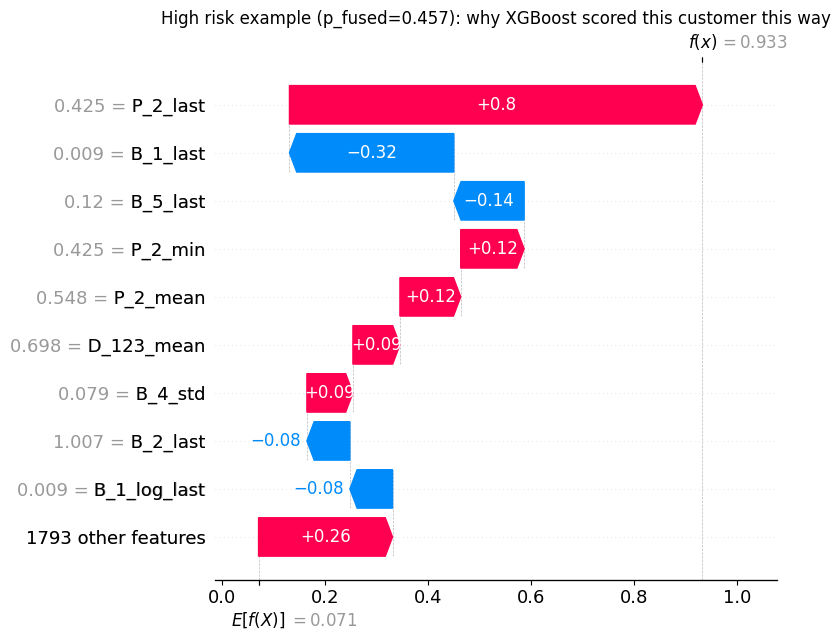

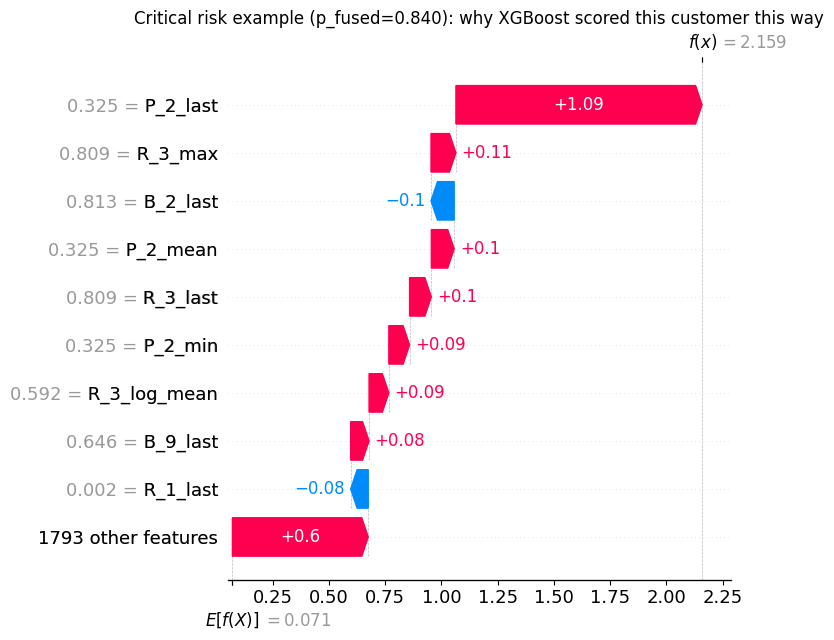

In [26]:
# --- Compute Branch 1's SHAP values for just these 4 customers, and plot a waterfall each ---
example_shap = {}
for level, cid in representative_customers.items():
    row = X_b1_test.loc[[cid]]
    sv = explainer_b1.shap_values(row)
    example_shap[level] = sv[0]

    exp = shap.Explanation(
        values=example_shap[level],
        base_values=explainer_b1.expected_value,
        data=X_b1_test.loc[cid].values,
        feature_names=B1_FEATURES
    )
    shap.plots.waterfall(exp, max_display=10, show=False)
    plt.title(f'{level} risk example (p_fused={representative_p[level]:.3f}): why XGBoost scored this customer this way')
    plt.tight_layout()
    plt.show()

**Insight:** For the Critical example (p_fused 0.841), check that the waterfall is dominated by features pushing toward default, with P_2 being low the most likely top driver, given every prior analysis in this project. For the Low example (p_fused 0.004), expect the opposite pattern, features pushing away from default. If a wrong-direction feature shows up prominently, that isn't necessarily a bug: real customers are mixed cases, and this is exactly the kind of individual nuance a single aggregate SHAP summary plot can't show.


## Step 15: A Distinct Card Design per Risk Level, Explaining the Full Fusion Decision

An earlier version of this card only showed Branch 1 (XGBoost)'s SHAP reasons, even though the actual decision comes from Fusion, which weighs XGBoost and GRU roughly equally (Step 11). Showing only one branch's reasoning was an incomplete, and potentially misleading, explanation of the real decision. Each card now shows two things beyond the color and recommended action: Fusion's contribution split for this specific customer, exactly how much of the final fused logit came from XGBoost against GRU (via `meta.coef_`), which can differ from customer to customer even though the average trust split is roughly balanced; and both branches' top reasons, XGBoost's from SHAP (Step 14) and GRU's own, a fresh, per-customer Grad x Input computation, not just the aggregate ranking from Step 12.

Each level still has its own color (`LEVEL_COLORS`) and recommended action (`RISK_ACTIONS`). This remains a design reference and mockup, not final production UI.


In [27]:
# Per-customer GRU saliency for the same 4 representative customers (not just the
# aggregate ranking from Step 12), and each customer's exact Fusion contribution split.
example_gru_reasons = {}
fusion_contribution = {}

for level, cid in representative_customers.items():
    # Find this customer's row in the test sequence array to compute their own gradient.
    cust_pos = np.where(ids_test == cid)[0][0]
    x_one = tf.convert_to_tensor(X_test_seq[cust_pos:cust_pos + 1], dtype=tf.float32)

    with tf.GradientTape() as tape:
        tape.watch(x_one)
        pred_one = branch2_model(x_one, training=False)[:, MAX_LEN - 1, 0]
    grad_one = tape.gradient(pred_one, x_one).numpy()[0]
    grad_x_input_one = grad_one * X_test_seq[cust_pos]   # (MAX_LEN, n_features)

    per_feature = np.abs(grad_x_input_one).sum(axis=0)   # summed across months for this customer
    top_idx = np.argsort(per_feature)[::-1][:3]
    signed_at_last_month = grad_x_input_one[MAX_LEN - 1]  # direction, from the last real month
    example_gru_reasons[level] = [
        f"{SEQ_COLS[i]}  ->  {'higher risk' if signed_at_last_month[i] > 0 else 'lower risk'}"
        for i in top_idx
    ]

    # Fusion contribution split for this exact customer (matches how `meta` combines them).
    row = last_test[last_test['customer_ID'] == cid].iloc[0]
    eps = 1e-6
    logit = lambda x: np.log(np.clip(x, eps, 1 - eps) / (1 - np.clip(x, eps, 1 - eps)))
    contrib_xgb = meta.coef_[0][0] * logit(row['p_xgb'])
    contrib_gru = meta.coef_[0][1] * logit(row['p_branch2'])
    total = abs(contrib_xgb) + abs(contrib_gru)
    fusion_contribution[level] = {
        'xgb_pct': abs(contrib_xgb) / total if total > 0 else 0.5,
        'gru_pct': abs(contrib_gru) / total if total > 0 else 0.5,
    }

print("Per-customer Fusion contribution split:")
for level in RISK_LEVELS:
    if level in fusion_contribution:
        fc = fusion_contribution[level]
        print(f"  {level:<10s}: XGBoost {fc['xgb_pct']:.0%} | GRU {fc['gru_pct']:.0%}")

Per-customer Fusion contribution split:
  Low       : XGBoost 48% | GRU 52%
  Moderate  : XGBoost 83% | GRU 17%
  High      : XGBoost 71% | GRU 29%
  Critical  : XGBoost 42% | GRU 58%


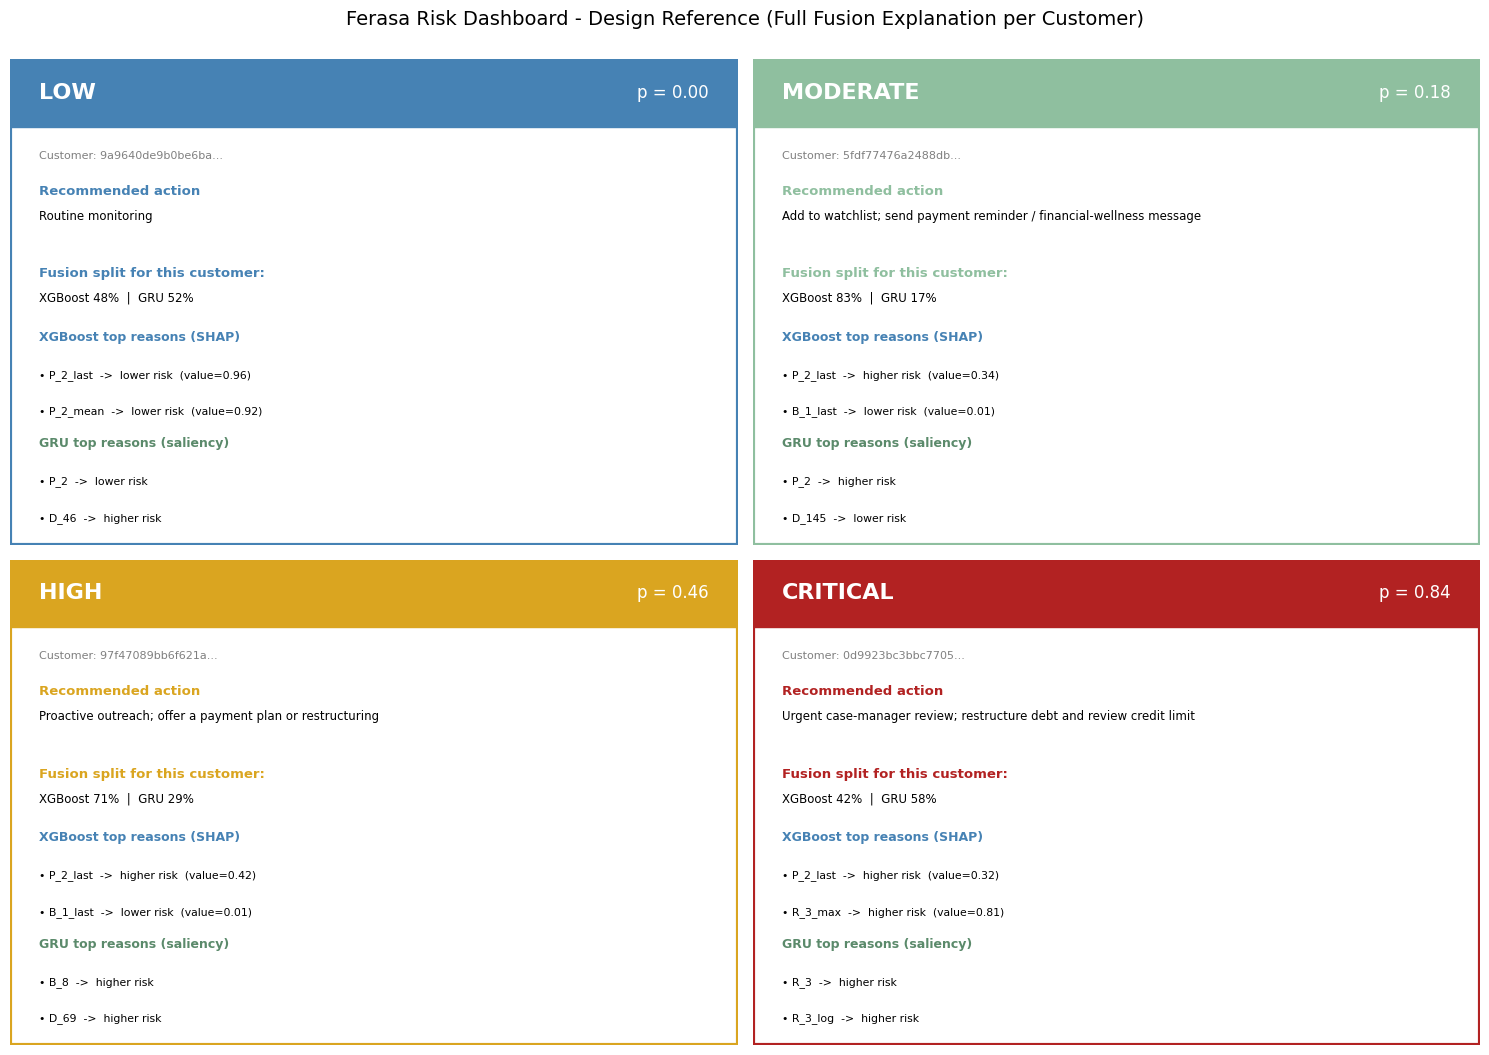

In [28]:
def top_reasons(shap_vals, feature_names, data_row, n=3):
    """Return the n biggest SHAP contributors for one customer, as readable strings."""
    top_idx = np.argsort(np.abs(shap_vals))[::-1][:n]
    lines = []
    for i in top_idx:
        feat = feature_names[i]
        direction = 'higher risk' if shap_vals[i] > 0 else 'lower risk'
        lines.append(f"{feat}  ->  {direction}  (value={data_row[i]:.2f})")
    return lines

fig, axes = plt.subplots(2, 2, figsize=(15, 10.5))
axes = axes.flatten()

for ax, level in zip(axes, RISK_LEVELS):
    ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.axis('off')
    if level not in representative_customers:
        ax.text(0.5, 0.5, f'No {level} examples\nin this test sample', ha='center', va='center')
        continue

    cid = representative_customers[level]
    p = representative_p[level]
    sv = example_shap[level]
    data_row = X_b1_test.loc[cid].values
    color = LEVEL_COLORS[level]
    xgb_reasons = top_reasons(sv, B1_FEATURES, data_row, n=2)
    gru_reasons = example_gru_reasons[level][:2]
    fc = fusion_contribution[level]

    # Card border
    ax.add_patch(plt.Rectangle((0.0, 0.0), 1.0, 1.0, fill=False, edgecolor=color, linewidth=3))
    # Header bar
    ax.add_patch(plt.Rectangle((0.0, 0.86), 1.0, 0.14, color=color))
    ax.text(0.04, 0.93, level.upper(), fontsize=16, fontweight='bold', color='white', va='center')
    ax.text(0.96, 0.93, f'p = {p:.2f}', fontsize=12, color='white', va='center', ha='right')

    # Body
    ax.text(0.04, 0.795, f'Customer: {str(cid)[:16]}...', fontsize=8, color='gray')

    ax.text(0.04, 0.72, 'Recommended action', fontsize=9.5, fontweight='bold', color=color)
    ax.text(0.04, 0.72, '\n' + RISK_ACTIONS[level], fontsize=8.5, va='top', wrap=True)

    # Fusion contribution split: shows how much each branch drove this decision
    ax.text(0.04, 0.55, "Fusion split for this customer:", fontsize=9.5, fontweight='bold', color=color)
    ax.text(0.04, 0.50, f"XGBoost {fc['xgb_pct']:.0%}  |  GRU {fc['gru_pct']:.0%}", fontsize=8.5)

    ax.text(0.04, 0.42, 'XGBoost top reasons (SHAP)', fontsize=9, fontweight='bold', color=MODEL_COLORS['XGBoost (Branch 1)'])
    for j, r in enumerate(xgb_reasons):
        ax.text(0.04, 0.36 - j * 0.075, f'\u2022 {r}', fontsize=7.8, va='top')

    ax.text(0.04, 0.20, 'GRU top reasons (saliency)', fontsize=9, fontweight='bold', color='#5B8A6B')
    for j, r in enumerate(gru_reasons):
        ax.text(0.04, 0.14 - j * 0.075, f'\u2022 {r}', fontsize=7.8, va='top')

plt.suptitle('Firasa Risk Dashboard - Design Reference (Full Fusion Explanation per Customer)',             fontsize=14, y=1.0)
plt.tight_layout()
plt.show()

**Insight:** All 4 cards rendered with real examples, and the per-customer Fusion split shows real variation around the average 51.6/48.4 trust split (toward XGBoost). Low splits 48/52 toward GRU, High splits 71/29 toward XGBoost, Critical splits 42/58 toward GRU, showing meaningful pull away from the average without being extreme. Moderate is the interesting case: 83% XGBoost against 17% GRU, meaning that decision was driven almost entirely by XGBoost's score. That is useful information, not noise: it is exactly the case where showing only Branch 2's (GRU's) reasoning would have been actively misleading, since XGBoost, not GRU, was the real decision-maker for that customer.

# Part D - Known Limitation: This Is a Customer-Level Split, Not a Time-Based Split

Every train, validation, and test split in this project separates customers: no customer's data appears in more than one split. This protects against customer-level leakage, in which the model has previously seen the same customer. The validation-to-test gap checks support that protection, with gaps below 0.002 throughout.

This design does not, by itself, demonstrate that the model will generalize to future periods. If the customers in the train, validation, and test sets have statement histories from approximately the same calendar period, the model has not been tested on a genuinely later time window. A true out-of-time evaluation ("training on an earlier period and testing on a strictly later period") would support a stronger claim. This distinction matters because credit risk can change with macroeconomic conditions that a same-period customer-level split cannot capture.

This section therefore reports a diagnostic of calendar overlap and states the appropriate remedy. It does not attempt to attach a partial temporal correction to a split that was not designed for that purpose.


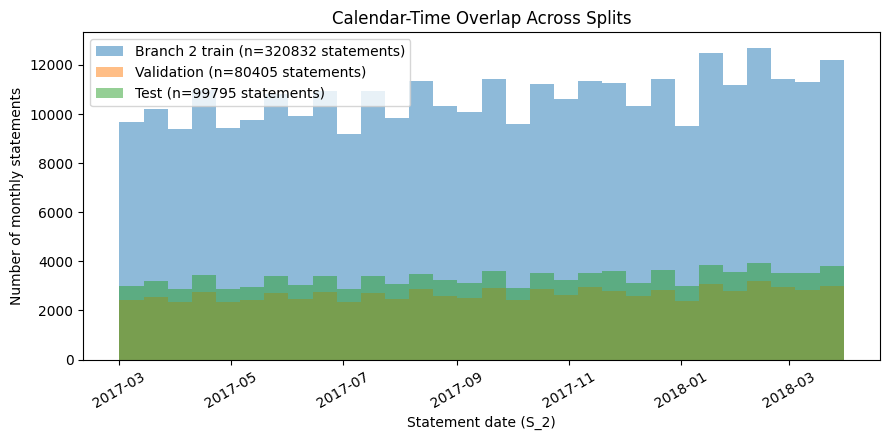

Branch 2 train  : 2017-03-01 to 2018-03-31
Validation      : 2017-03-01 to 2018-03-31
Test            : 2017-03-01 to 2018-03-31


In [29]:
fig, ax = plt.subplots(figsize=(9, 4.5))

splits = {
    'Branch 2 train': train_df[train_df['customer_ID'].isin(tr_ids)]['S_2'],
    'Validation':      train_df[train_df['customer_ID'].isin(val_ids)]['S_2'],
    'Test':            test_df['S_2'],
}

for name, dates in splits.items():
    ax.hist(pd.to_datetime(dates), bins=30, alpha=0.5, label=f'{name} (n={len(dates)} statements)')

ax.set_xlabel('Statement date (S_2)')
ax.set_ylabel('Number of monthly statements')
ax.set_title('Calendar-Time Overlap Across Splits')
ax.legend()
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

for name, dates in splits.items():
    d = pd.to_datetime(dates)
    print(f"{name:<16}: {d.min().date()} to {d.max().date()}")

**Insight:** The three splits span the exact same calendar range, **2017-03-01 to 2018-03-31**. This confirms that the current evaluation measures customer-level generalisation rather than true out-of-time performance; there is no temporal separation between the splits.

A proper temporal validation would require redefining the split from the EDA stage onward: select a cutoff date, train and validate on observations before the cutoff, test on observations after it, and rebuild both branches' features under the new split. The customer-level and out-of-time scores should then be reported separately because they answer different evaluation questions.

This is a clearly identified methodological limitation and a well-scoped next step, not a result to conceal.
